# DATA CHALLENGE

# 1. Load and Convert Data 
### Test avec Contrast Limited Adaptive Histogram Equalization (CLAHE)

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_12623/3307770978.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image)
/opt/anaconda3/envs/phelma/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


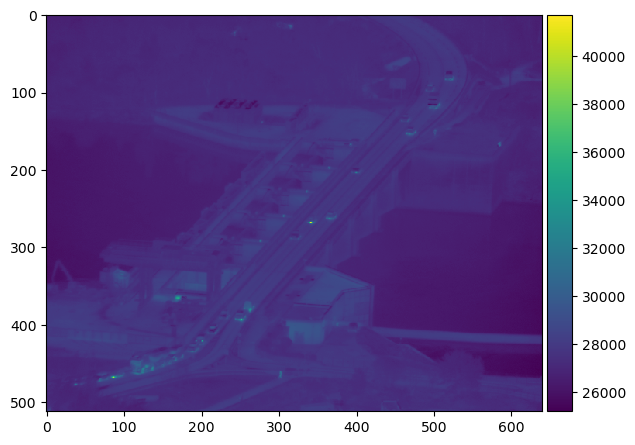

In [3]:
from skimage import io
image=io.imread('images/frame_0000.png')
io.imshow(image)

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_12623/2076493587.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final_simple)


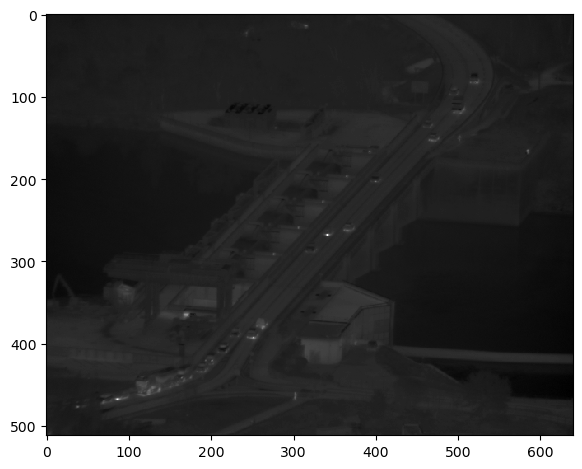

In [13]:
img_final_simple = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
img_final_simple = img_final_simple.astype(np.uint8)
io.imshow(img_final_simple)

#### en utilisant CLAHE (=Contrast Limited Adaptive Histogram Equalization)

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_12623/881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


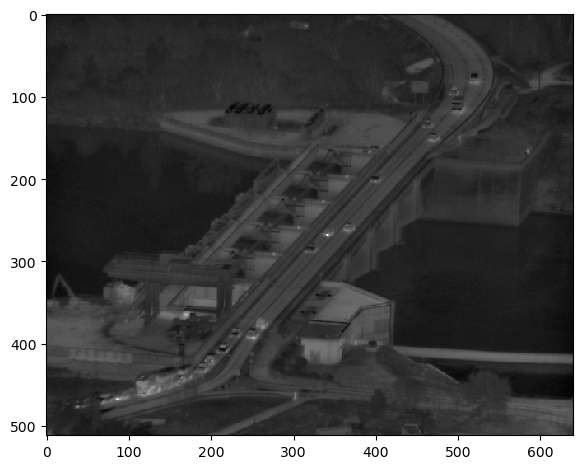

In [15]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

#### Compare 2 methods 

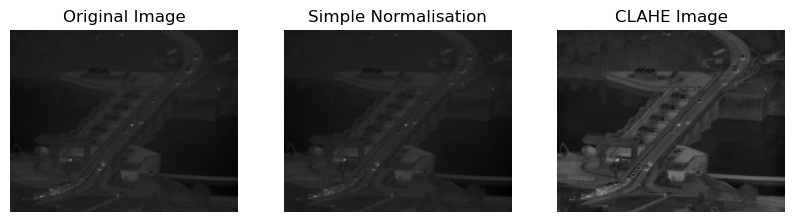

In [16]:
# plot images with both images 
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(img_final_simple, cmap='gray')
axs[1].set_title('Simple Normalisation')
axs[1].axis('off')
axs[2].imshow(img_final, cmap='gray')
axs[2].set_title('CLAHE Image')
axs[2].axis('off')
plt.show()